In [1]:
# ==================================================================
# YOLO + OCR 추론 노트북
# 목적: 학습된 YOLO 모델로 닉네임 영역을 검출하고 OCR로 텍스트를 추출
# ==================================================================

from pathlib import Path

# 현재 노트북은 notebooks 폴더 안에 있으므로
# 상위 폴더를 프로젝트 루트로 설정
PROJECT_ROOT = Path.cwd().parent

# 학습된 최종 YOLOv8s-960 모델 경로
BEST_MODEL = (
    PROJECT_ROOT
    / "runs"
    / "detect"
    / "ns_yolov8s_960"
    / "weights"
    / "best.pt"
)

# 테스트 이미지 폴더 경로
TEST_IMAGES = PROJECT_ROOT / "data" / "test" / "images"

print("프로젝트 루트:", PROJECT_ROOT)
print("모델 존재 여부:", BEST_MODEL.exists())
print("테스트 이미지 폴더 존재 여부:", TEST_IMAGES.exists())

프로젝트 루트: c:\Users\금정산2-PC16\Desktop\NS-Project
모델 존재 여부: True
테스트 이미지 폴더 존재 여부: True


In [2]:
# ==================================================
# 라이브러리 불러오기 및 YOLO 모델 로드
# ==================================================

from ultralytics import YOLO
from IPython.display import Image, display
import cv2

# 학습된 YOLOv8s-960 best 모델 불러오기
model = YOLO(str(BEST_MODEL))

# 모델 클래스 이름 확인
print(model.names)

{0: 'user_character', 1: 'user_id'}


In [3]:
# ==================================================
# 테스트 이미지 1장 선택 후 YOLO 예측 수행
# ==================================================

# 테스트 이미지 목록 가져오기
test_image_list = list(TEST_IMAGES.glob("*"))

# 첫 번째 테스트 이미지 선택
img_path = test_image_list[0]

print("테스트 이미지:", img_path)

# YOLO 예측 수행
results = model.predict(
    source=str(img_path),
    imgsz=960,
    conf=0.5,
    device=0,
    save=True
)

# 예측 결과 요약 출력
print(results[0].boxes)

테스트 이미지: c:\Users\금정산2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0304_115450606.jpg

image 1/1 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0304_115450606.jpg: 512x960 1 user_character, 1 user_id, 28.9ms
Speed: 3.6ms preprocess, 28.9ms inference, 6.9ms postprocess per image at shape (1, 3, 512, 960)
Results saved to C:\Users\2-PC16\Desktop\NS-Project\runs\detect\predict-4
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 0.], device='cuda:0')
conf: tensor([0.8425, 0.7728], device='cuda:0')
data: tensor([[609.6442, 297.2996, 709.6865, 322.4576,   0.8425,   1.0000],
        [569.7432, 366.7794, 705.9404, 609.9750,   0.7728,   0.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (900, 1772)
shape: torch.Size([2, 6])
xywh: tensor([[659.6653, 309.8786, 100.0423,  25.1580],
        [637.8418, 488.3772, 136.1972, 243.1956]], device='cuda:0')
xywhn: tensor([[0.3723, 0.3443, 0.0565, 0.0280],
        [0.3600, 0.5426, 0.0769,

최근 예측 결과 폴더: c:\Users\금정산2-PC16\Desktop\NS-Project\runs\detect\predict-4


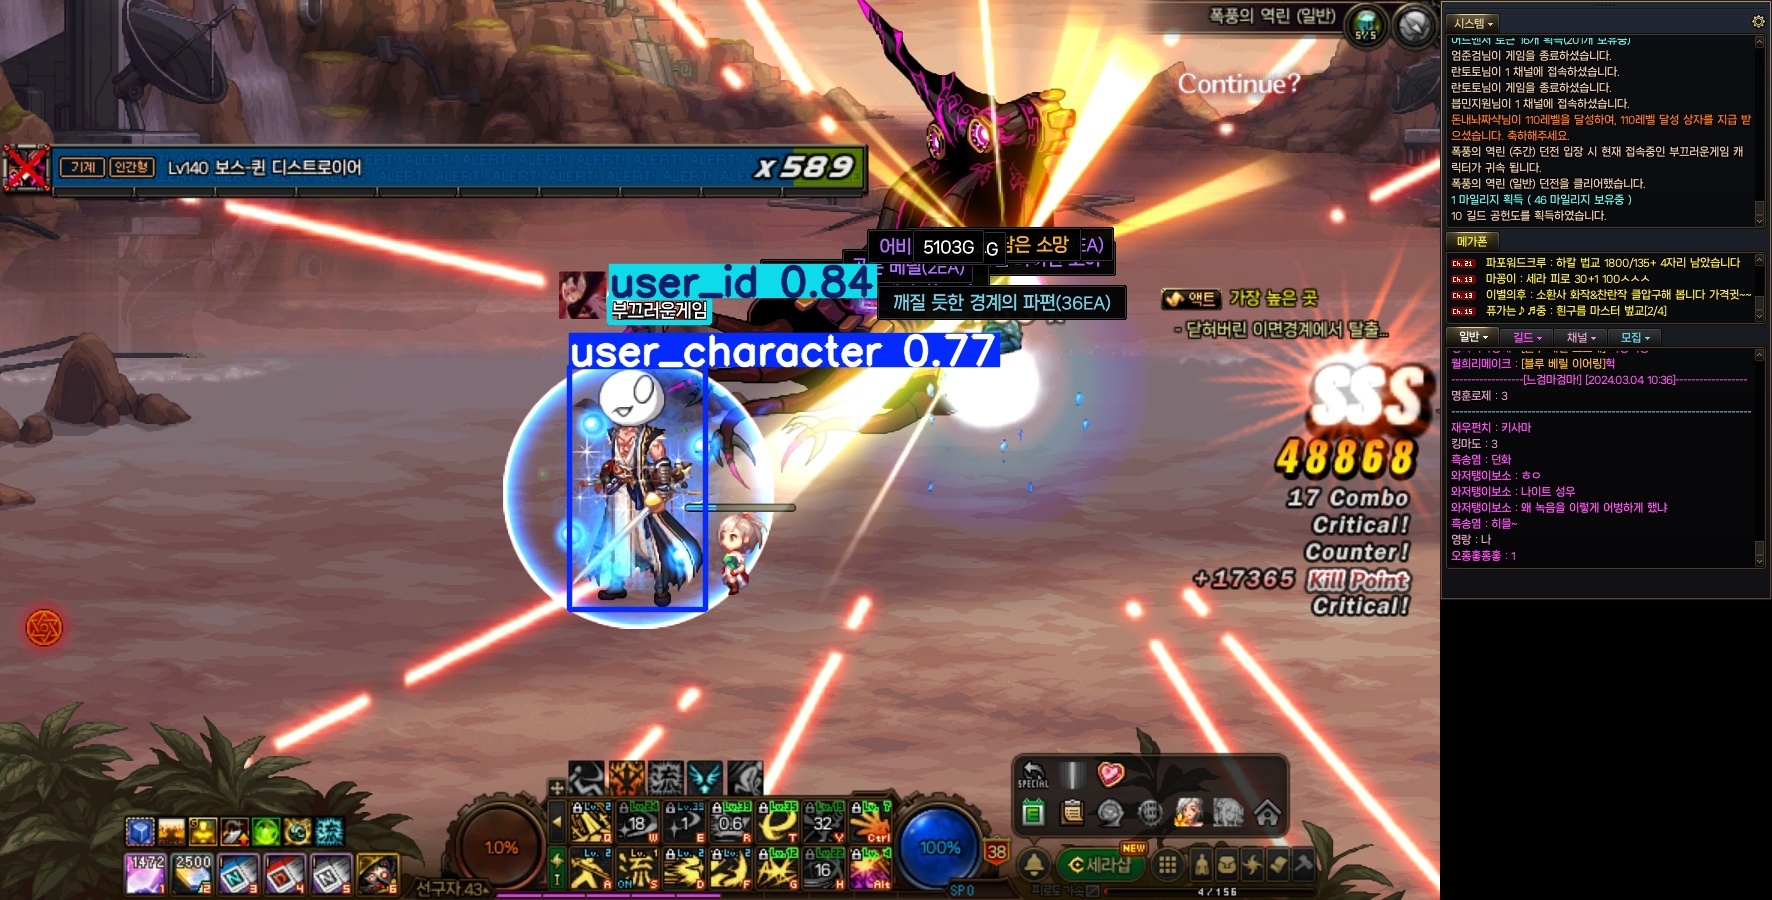

In [4]:
# ==================================================
# YOLO 예측 결과 이미지 확인
# ==================================================

from IPython.display import Image, display
from pathlib import Path

# 가장 최근 predict 폴더 찾기
predict_dirs = sorted(
    (PROJECT_ROOT / "runs" / "detect").glob("predict*"),
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

latest_predict_dir = predict_dirs[0]

print("최근 예측 결과 폴더:", latest_predict_dir)

# 예측 결과 이미지 출력
for img in latest_predict_dir.glob("*"):
    display(Image(filename=str(img)))

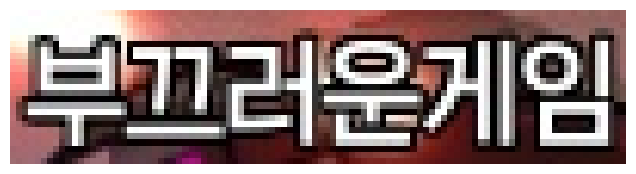

In [16]:
# ==================================================
# user_id 영역 Crop
# 목적: YOLO가 탐지한 닉네임 영역만 잘라서 OCR 입력으로 사용
# ==================================================

import cv2
import matplotlib.pyplot as plt

# 원본 이미지 읽기
img = cv2.imread(str(img_path))

# user_id crop 결과 저장 변수
crop = None

# YOLO 예측 박스 순회
for box in results[0].boxes:

    # 클래스 ID와 클래스 이름 확인
    cls_id = int(box.cls[0])
    class_name = model.names[cls_id]

    # 닉네임 클래스(user_id)만 선택
    if class_name == "user_id":

        # 박스 좌표 추출
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # 원본 이미지에서 닉네임 영역 crop
        crop = img[y1:y2, x1:x2]

        # crop 결과 확인
        plt.figure(figsize=(8, 2))
        plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

        break

# user_id가 탐지되지 않았을 경우
if crop is None:
    print("user_id 영역을 찾지 못했습니다.")

In [17]:
# ==================================================
# EasyOCR Reader 생성
# 목적: 한글과 영어 닉네임 인식을 위한 OCR 객체 생성
# ==================================================

import easyocr

# 한글 + 영어 OCR Reader 생성
# gpu=True: CUDA 사용 가능하면 GPU로 OCR 수행
reader = easyocr.Reader(["ko", "en"], gpu=True)

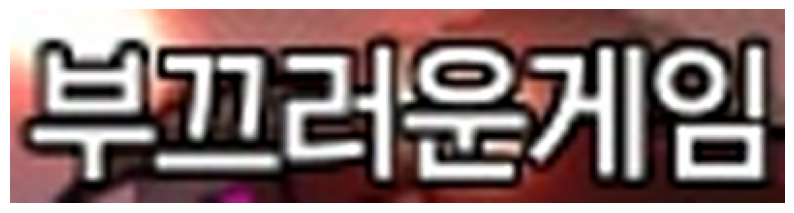

OCR 원본: 부끄러움게임
OCR 신뢰도: 0.8789031475603555


In [18]:
# ==================================================
# OCR 적용
# 목적: crop된 닉네임 이미지에서 텍스트 추출
# ==================================================

# OCR 인식률 향상을 위해 crop 이미지 확대
crop_big = cv2.resize(
    crop,
    None,
    fx=4,
    fy=4,
    interpolation=cv2.INTER_CUBIC
)

# 확대된 crop 이미지 확인
plt.figure(figsize=(10, 3))
plt.imshow(cv2.cvtColor(crop_big, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# EasyOCR 실행
ocr_result = reader.readtext(
    crop_big,
    detail=1,
    paragraph=False,
    text_threshold=0.4,
    low_text=0.2,
    link_threshold=0.4,
    mag_ratio=2
)

# OCR 결과 출력
for bbox, text, conf in ocr_result:
    print("OCR 원본:", text)
    print("OCR 신뢰도:", conf)

In [19]:
# ==================================================
# OCR 후처리
# 목적: 게임 폰트 특성으로 인해 자주 발생하는 OCR 오인식 보정
# ==================================================

def correct_nickname(text):
    corrections = {
        "부끄러움게임": "부끄러운게임",
    }

    return corrections.get(text, text)

In [20]:
# ==================================================
# 최종 OCR 결과 출력
# 목적: OCR 원본 텍스트와 후처리된 닉네임을 함께 확인
# ==================================================

for bbox, text, conf in ocr_result:
    corrected_text = correct_nickname(text)

    print("OCR 원본:", text)
    print("보정 결과:", corrected_text)
    print("신뢰도:", conf)

OCR 원본: 부끄러움게임
보정 결과: 부끄러운게임
신뢰도: 0.8789031475603555


---

In [21]:
# ==================================================
# OCR 결과 저장용 리스트 생성
# 목적: 이미지별 OCR 결과를 저장
# ==================================================

result_rows = []

In [22]:
# ==================================================
# 테스트 이미지 전체 OCR 수행
# 목적: test/images 폴더의 모든 이미지 처리
# ==================================================

for img_path in TEST_IMAGES.glob("*"):

    print(f"\n처리중 : {img_path.name}")

    # YOLO 예측
    results = model.predict(
        source=str(img_path),
        imgsz=960,
        conf=0.5,
        device=0,
        verbose=False
    )

    # 원본 이미지 읽기
    img = cv2.imread(str(img_path))

    # user_id 탐지 여부
    found = False

    for box in results[0].boxes:

        cls_id = int(box.cls[0])
        class_name = model.names[cls_id]

        # user_id만 OCR 수행
        if class_name == "user_id":

            found = True

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            crop = img[y1:y2, x1:x2]

            crop_big = cv2.resize(
                crop,
                None,
                fx=4,
                fy=4,
                interpolation=cv2.INTER_CUBIC
            )

            ocr_result = reader.readtext(
                crop_big,
                detail=1,
                paragraph=False,
                text_threshold=0.4,
                low_text=0.2,
                link_threshold=0.4,
                mag_ratio=2
            )

            # OCR 결과 저장
            for bbox, text, conf in ocr_result:

                corrected_text = correct_nickname(text)

                result_rows.append({
                    "filename": img_path.name,
                    "ocr_text": text,
                    "nickname": corrected_text,
                    "ocr_confidence": round(conf, 4)
                })

    # user_id 탐지 실패
    if not found:

        result_rows.append({
            "filename": img_path.name,
            "ocr_text": None,
            "nickname": None,
            "ocr_confidence": None
        })


처리중 : ScreenShot2024_0304_115450606.jpg

처리중 : ScreenShot2024_0304_141339663.jpg

처리중 : ScreenShot2024_0307_222002013.jpg

처리중 : ScreenShot2024_0307_231808909.jpg

처리중 : ScreenShot2024_0307_234814460.jpg

처리중 : ScreenShot2024_0308_005112729.jpg

처리중 : ScreenShot2024_0308_213117869.jpg

처리중 : ScreenShot2024_0308_225451866.jpg

처리중 : ScreenShot2024_0309_195729375.jpg

처리중 : ScreenShot2024_0309_202918770.jpg

처리중 : ScreenShot2024_0310_191122177.jpg

처리중 : ScreenShot2024_0310_194737263.jpg

처리중 : ScreenShot2024_0311_164506563.jpg

처리중 : ScreenShot2024_0311_181930117.jpg

처리중 : ScreenShot2024_0311_182406074.jpg

처리중 : ScreenShot2024_0311_182447074.jpg

처리중 : ScreenShot2024_0312_121803791.jpg

처리중 : ScreenShot2024_0314_004025247.jpg

처리중 : ScreenShot2024_0314_021040099.jpg

처리중 : ScreenShot2024_0314_161245344.jpg

처리중 : ScreenShot2024_0314_191918145.jpg

처리중 : ScreenShot2024_0314_220100769.jpg

처리중 : ScreenShot2024_0315_015624003.jpg

처리중 : ScreenShot2024_0315_050405529.jpg

처리중 : ScreenSho

In [23]:
# ==================================================
# OCR 결과 DataFrame 생성
# 목적: 결과를 표 형태로 확인
# ==================================================

import pandas as pd

result_df = pd.DataFrame(result_rows)

result_df

,filename,ocr_text,nickname,ocr_confidence
0,ScreenShot2024_0304_115450606.jpg,부끄러움게임,부끄러운게임,0.8789
1,ScreenShot2024_0304_141339663.jpg,어운게임,어운게임,0.3068
2,ScreenShot2024_0307_222002013.jpg,부끄러운게임,부끄러운게임,0.9928
3,ScreenShot2024_0307_231808909.jpg,NaN,NaN,NaN
4,ScreenShot2024_0307_234814460.jpg,@웬한자),@웬한자),0.0164
...,...,...,...,...
164,ScreenShot2025_1011_111835902.jpg,키메라3호기,키메라3호기,0.9728
165,ScreenShot2025_1012_102530892.jpg,현트래물러,현트래물러,0.6131
166,ScreenShot2025_1015_021459396.jpg,키메라3호기,키메라3호기,0.9932
167,ScreenShot2025_1015_021623232.jpg,NaN,NaN,NaN


In [24]:
# ==================================================
# OCR 결과 CSV 저장
# 목적: 프로젝트 결과물 저장
# ==================================================

csv_path = PROJECT_ROOT / "ocr_result.csv"

result_df.to_csv(
    csv_path,
    index=False,
    encoding="utf-8-sig"
)

print(csv_path)

c:\Users\금정산2-PC16\Desktop\NS-Project\ocr_result.csv


In [25]:
# ==================================================
# OCR 성공률 계산
# 목적: OCR이 몇 장의 이미지에서 성공했는지 확인
# ==================================================

total_count = len(result_df)

success_count = result_df["nickname"].notna().sum()

print("전체 이미지 :", total_count)
print("성공 이미지 :", success_count)
print("성공률 :", round(success_count / total_count * 100, 2), "%")

전체 이미지 : 169
성공 이미지 : 145
성공률 : 85.8 %


In [26]:
# ==================================================
# OCR 실패 이미지 확인
# 목적: user_id 탐지 실패 또는 OCR 실패 이미지 목록 확인
# ==================================================

fail_df = result_df[result_df["nickname"].isna()]

print("실패 이미지 수:", len(fail_df))
fail_df

실패 이미지 수: 24


,filename,ocr_text,nickname,ocr_confidence
3,ScreenShot2024_0307_231808909.jpg,NaN,NaN,NaN
12,ScreenShot2024_0310_191122177.jpg,NaN,NaN,NaN
17,ScreenShot2024_0311_182447074.jpg,NaN,NaN,NaN
26,ScreenShot2024_0316_182000455.jpg,NaN,NaN,NaN
27,ScreenShot2024_0316_182600968.jpg,NaN,NaN,NaN
47,ScreenShot2024_0319_042028086.jpg,NaN,NaN,NaN
53,ScreenShot2024_0320_012256769.jpg,NaN,NaN,NaN
54,ScreenShot2024_0320_012420718.jpg,NaN,NaN,NaN
88,ScreenShot2025_0228_221905883.jpg,NaN,NaN,NaN
89,ScreenShot2025_0228_221911349.jpg,NaN,NaN,NaN


ScreenShot2024_0307_231808909.jpg


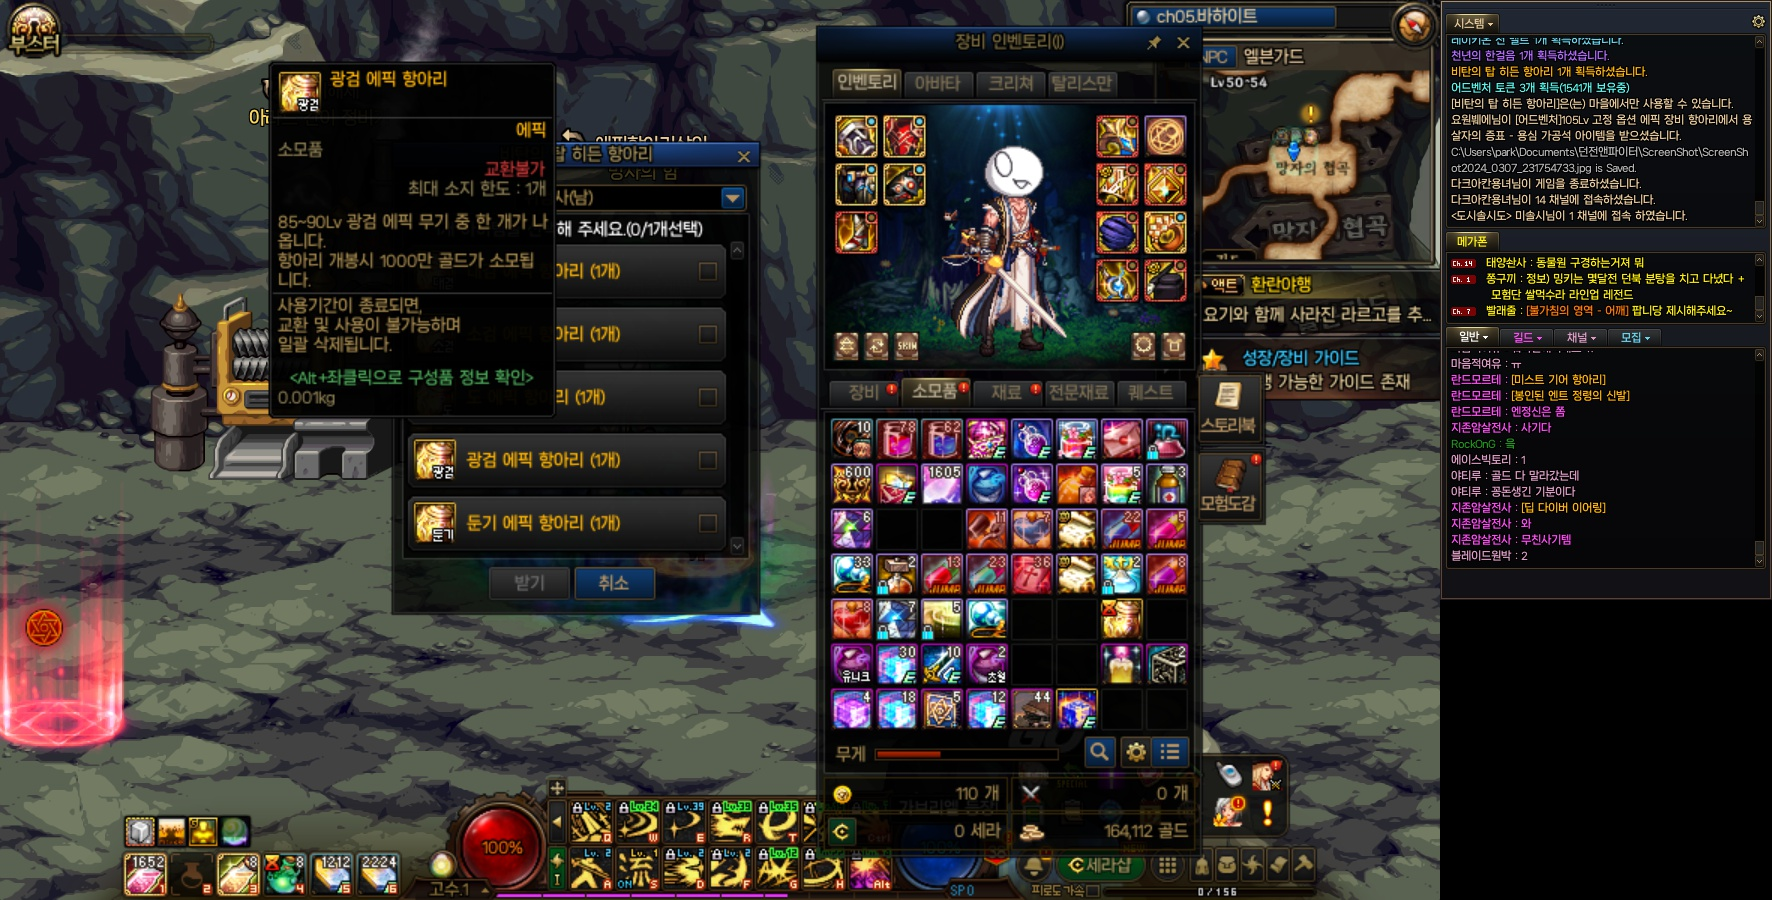

ScreenShot2024_0310_191122177.jpg


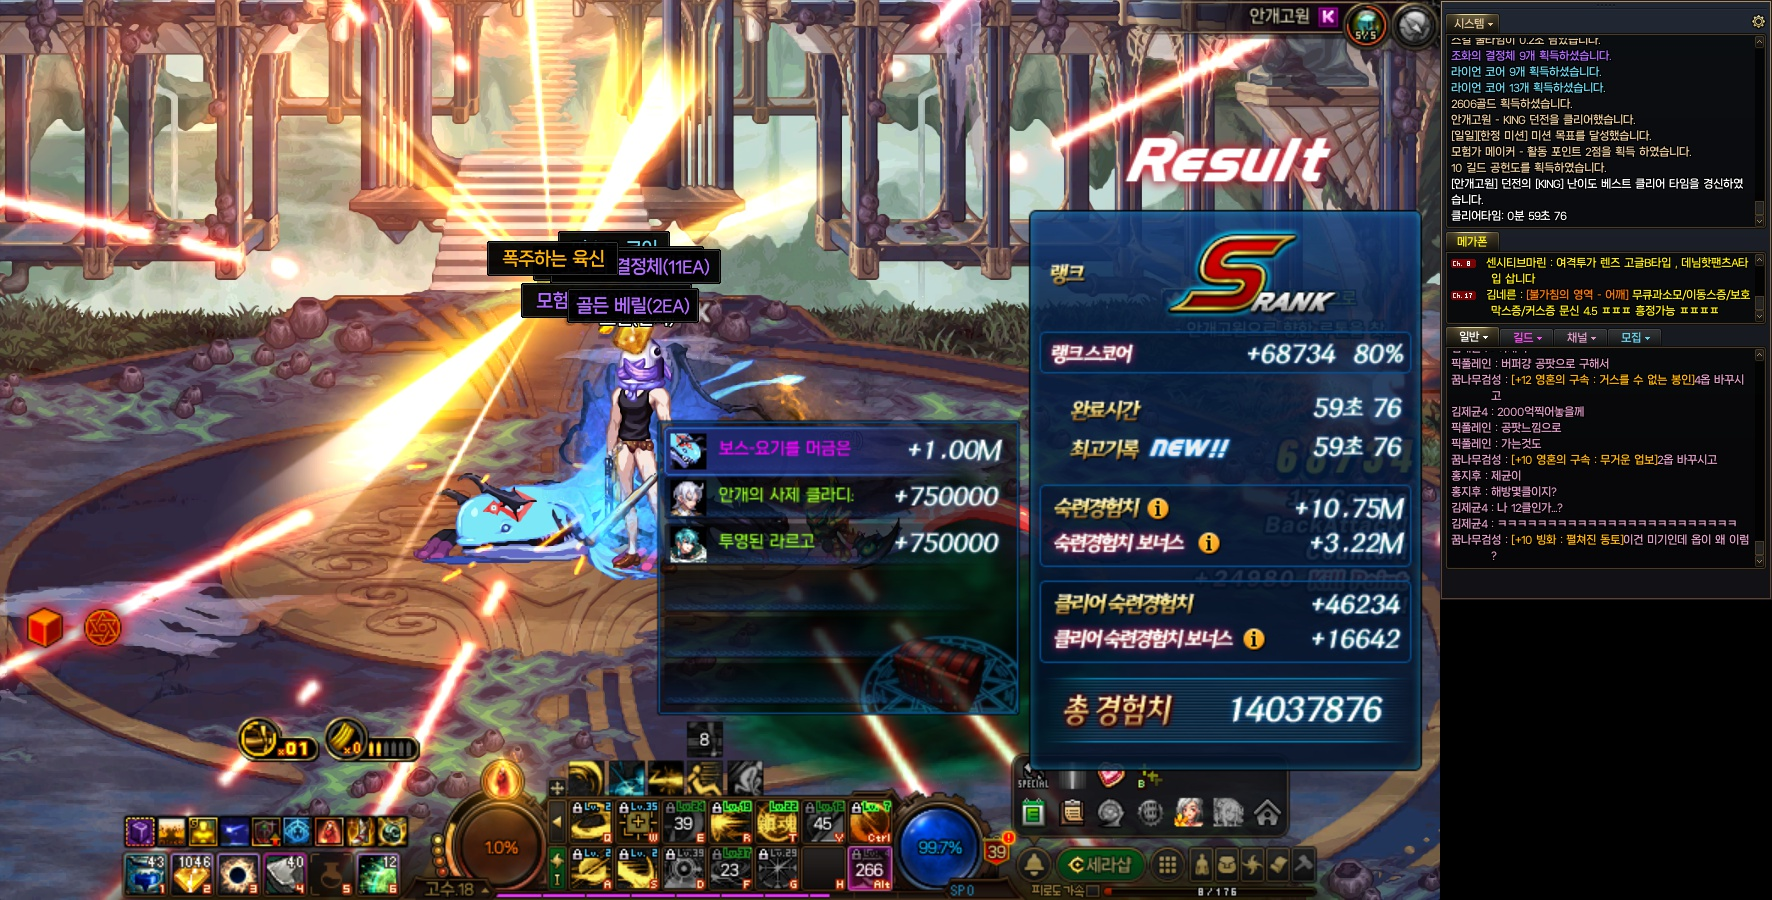

ScreenShot2024_0311_182447074.jpg


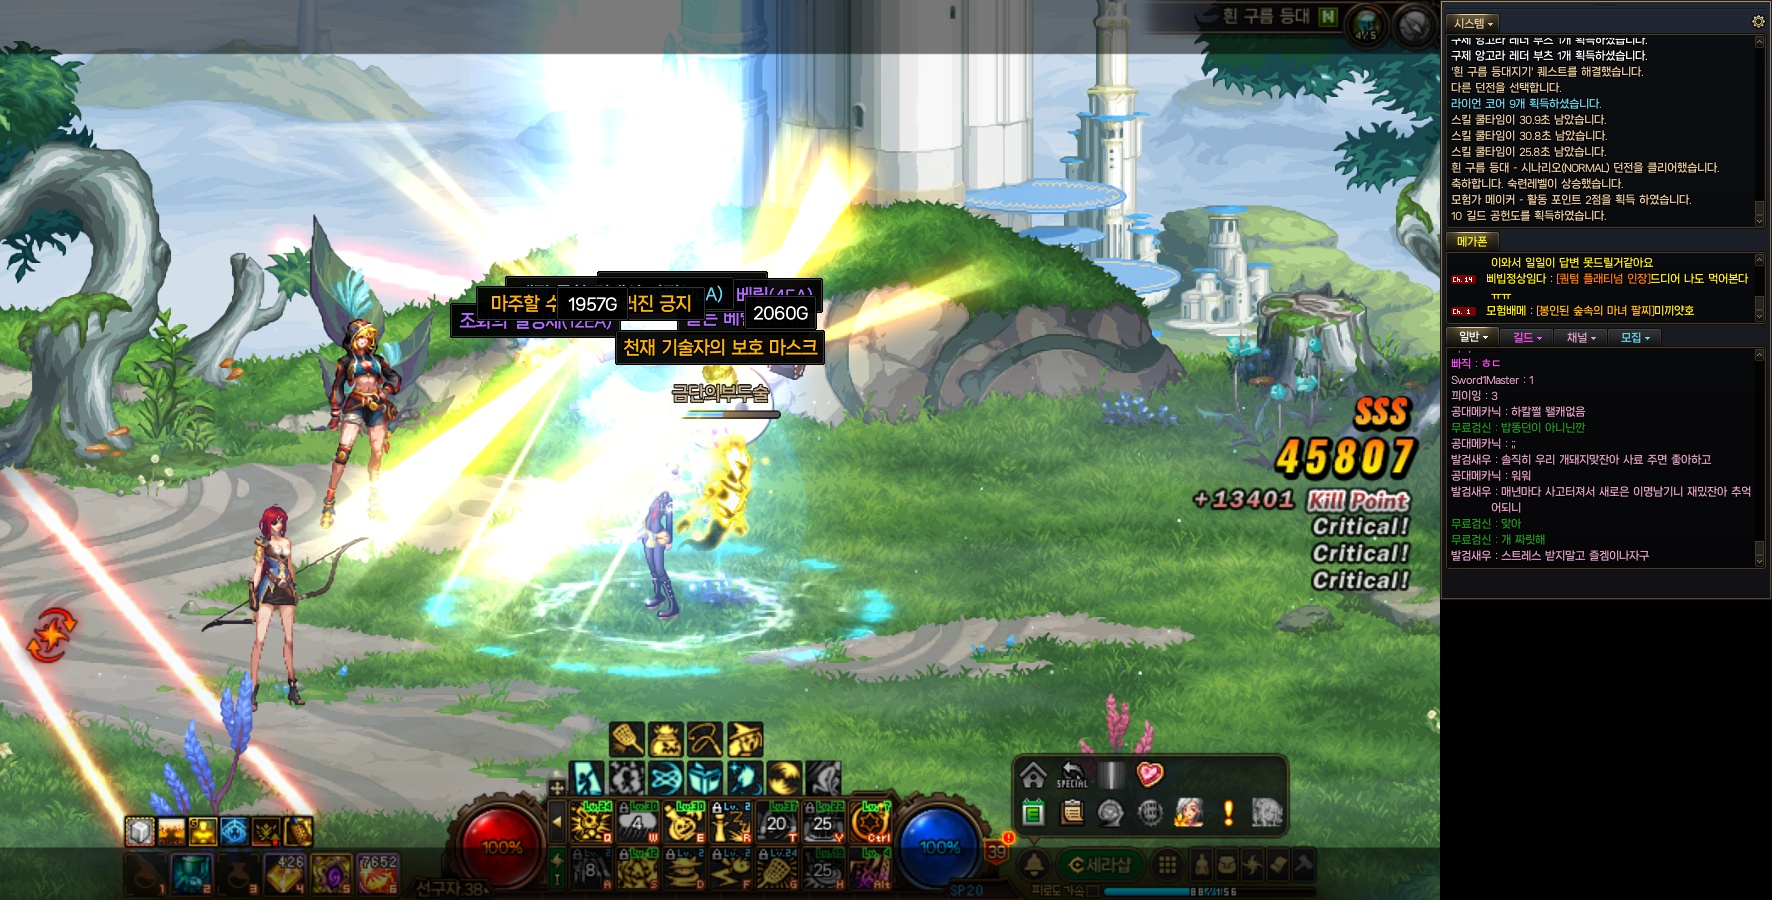

ScreenShot2024_0316_182000455.jpg


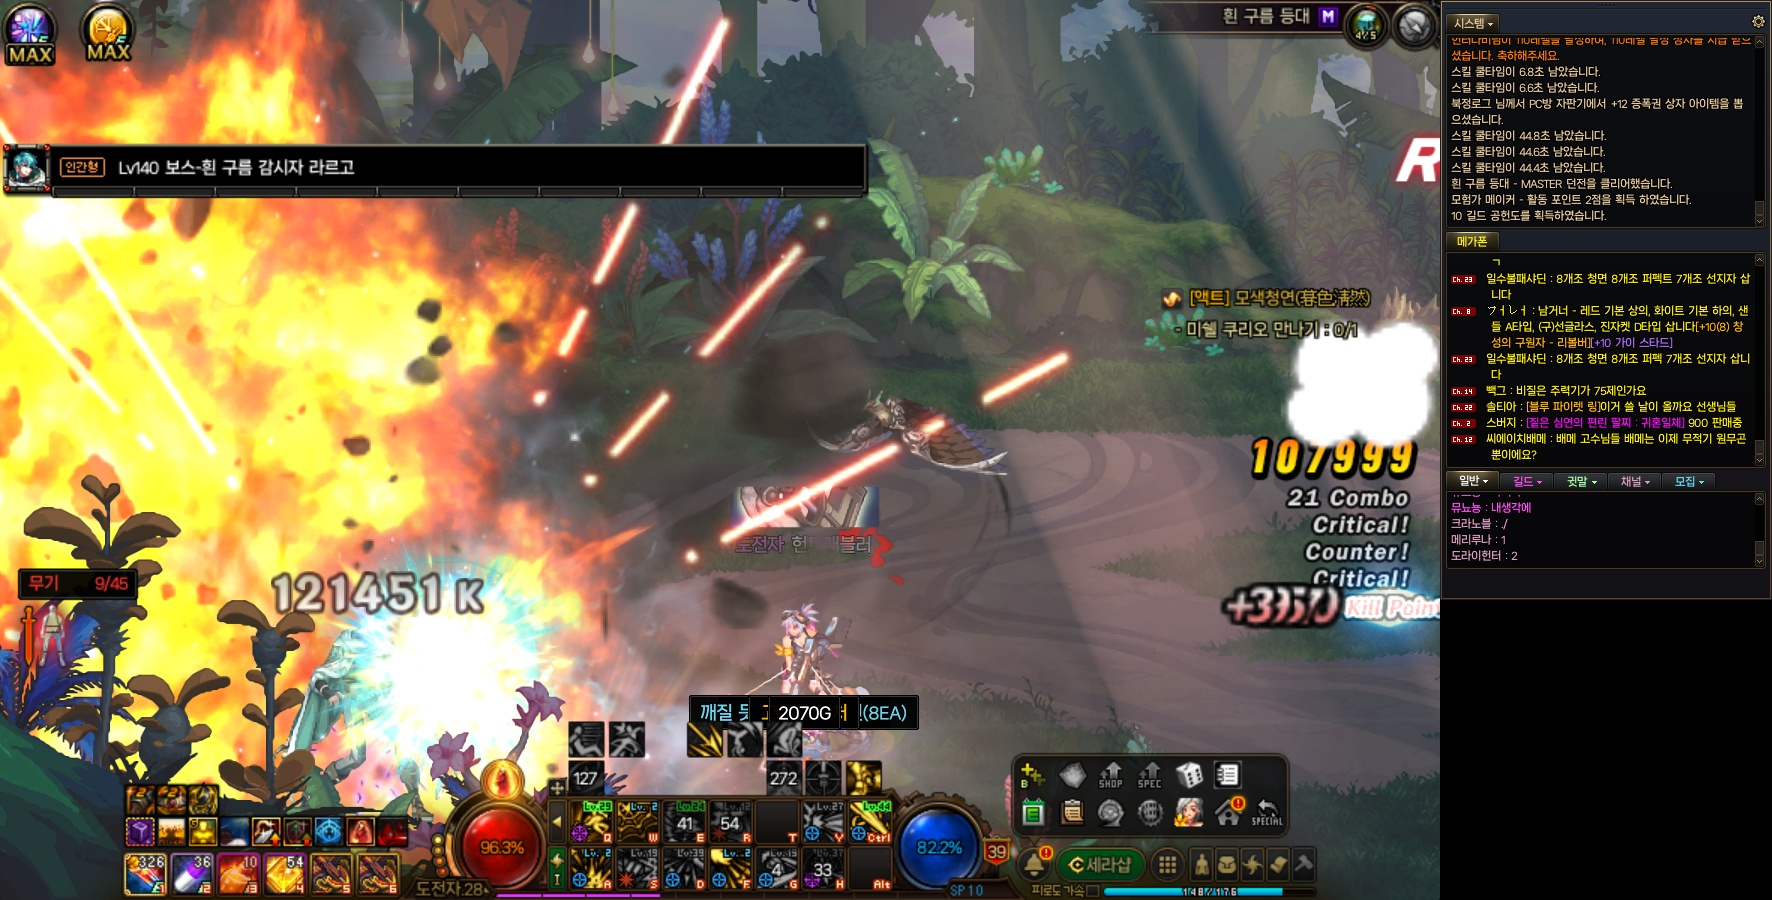

ScreenShot2024_0316_182600968.jpg


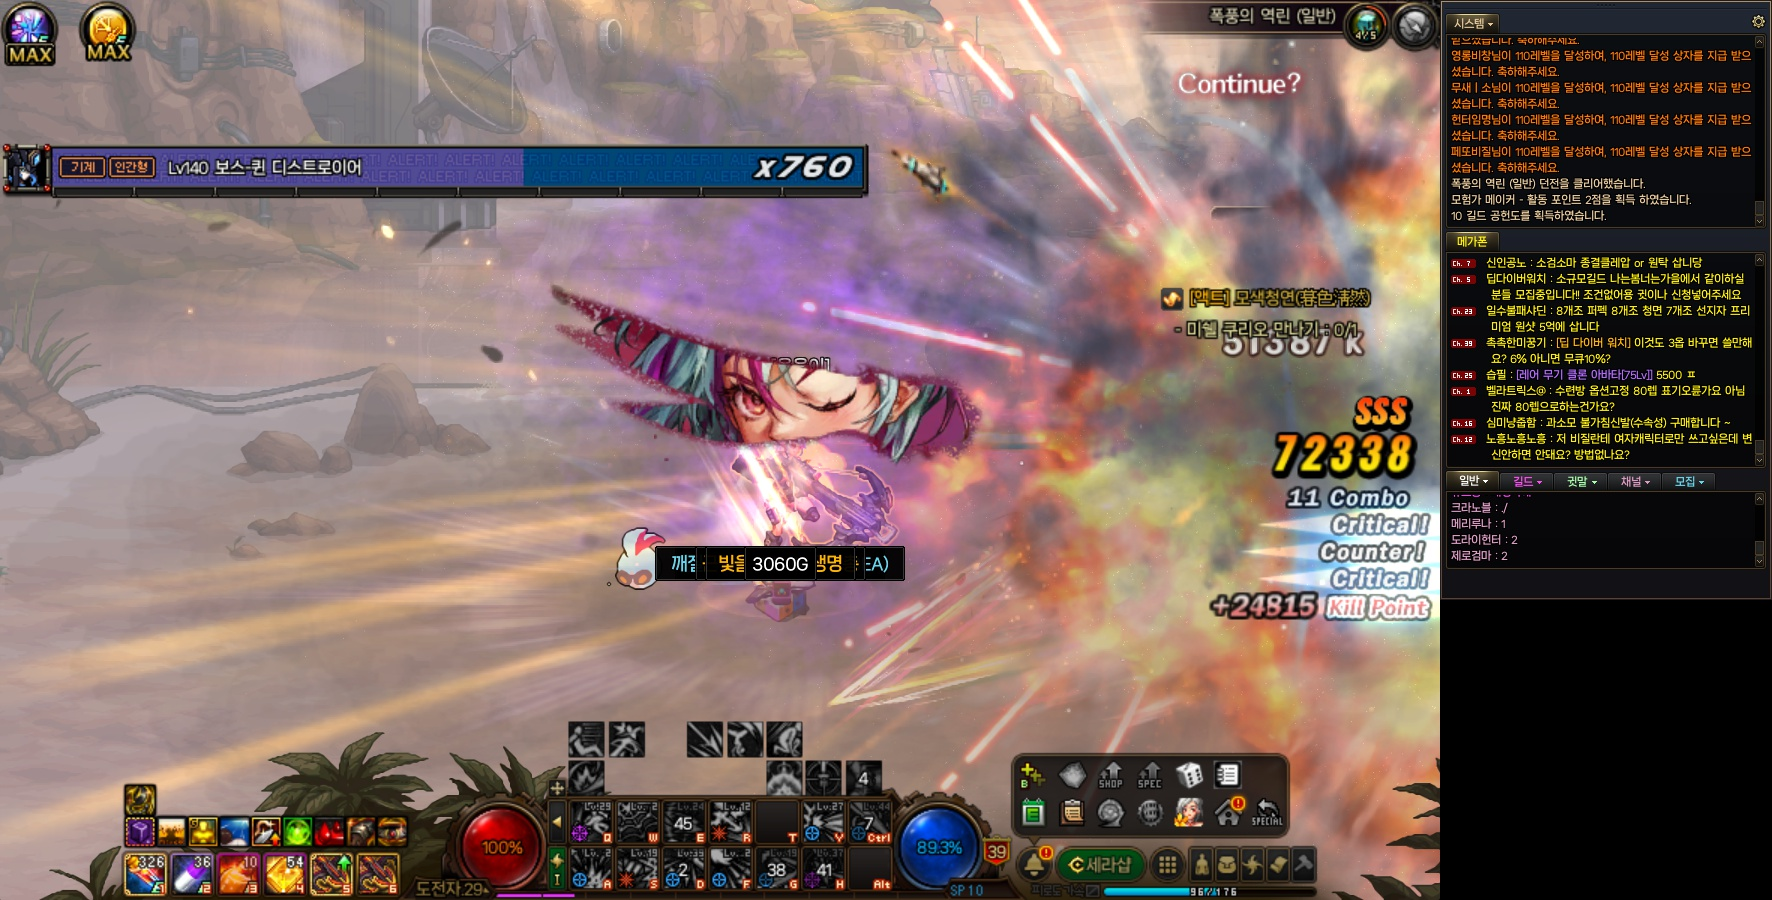

ScreenShot2024_0319_042028086.jpg


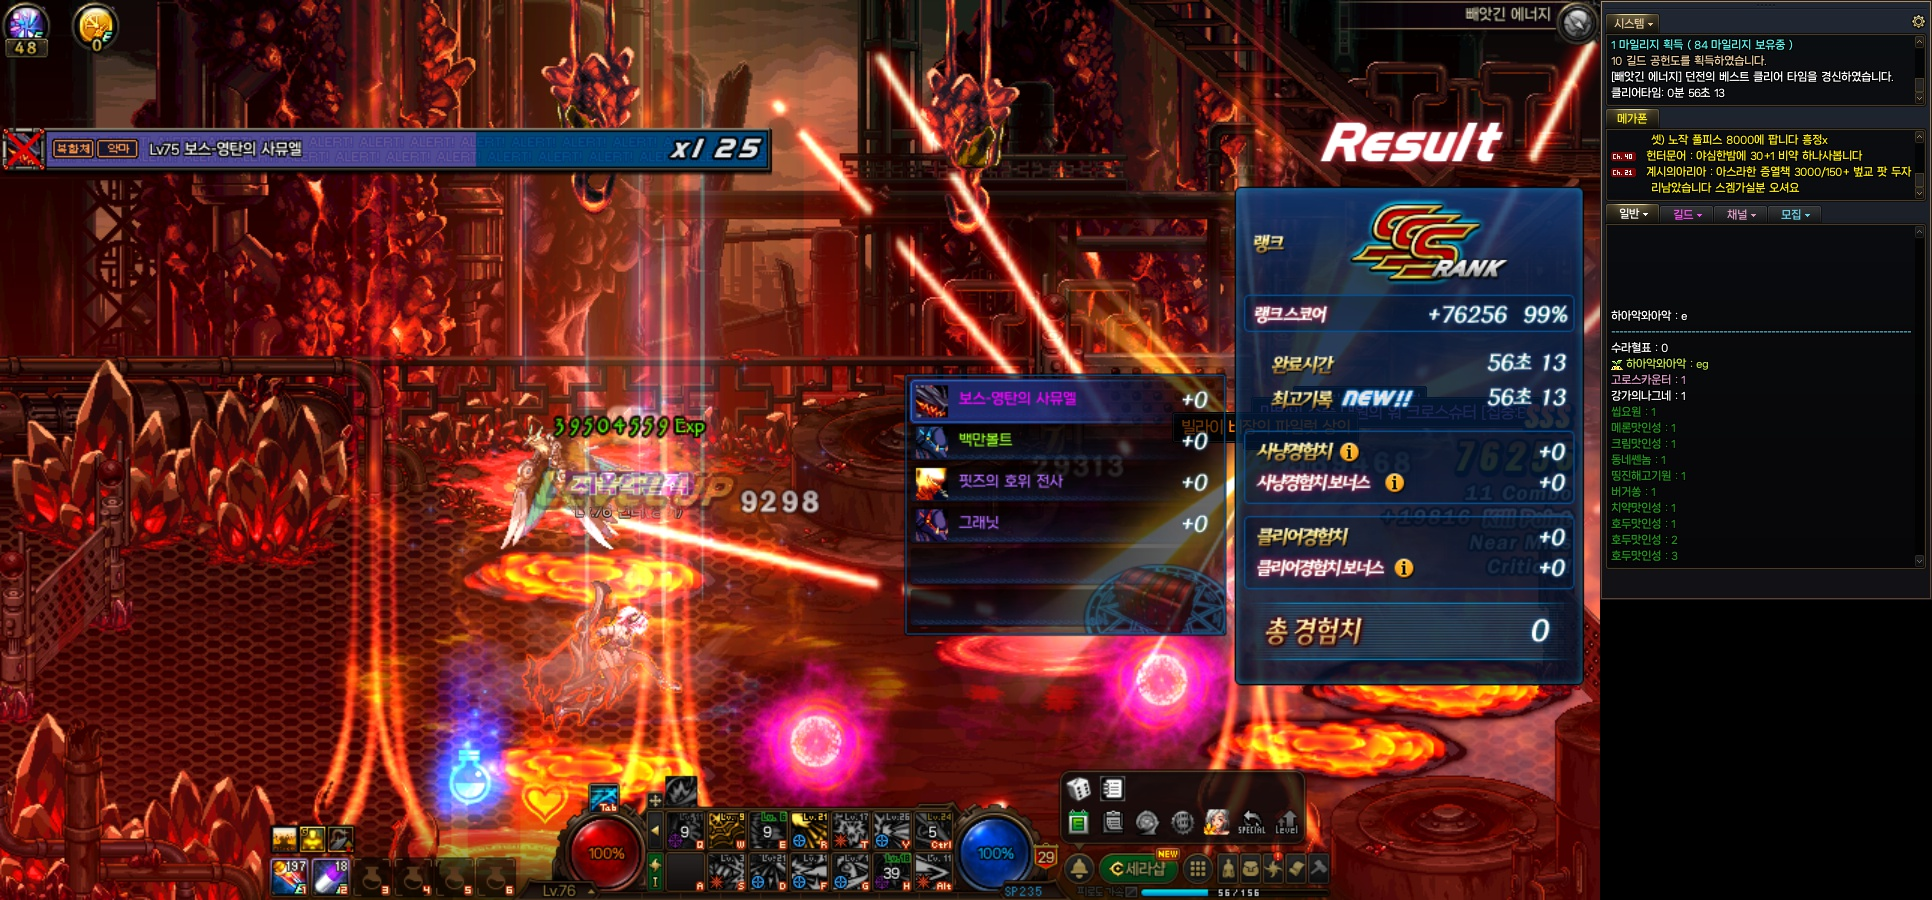

ScreenShot2024_0320_012256769.jpg


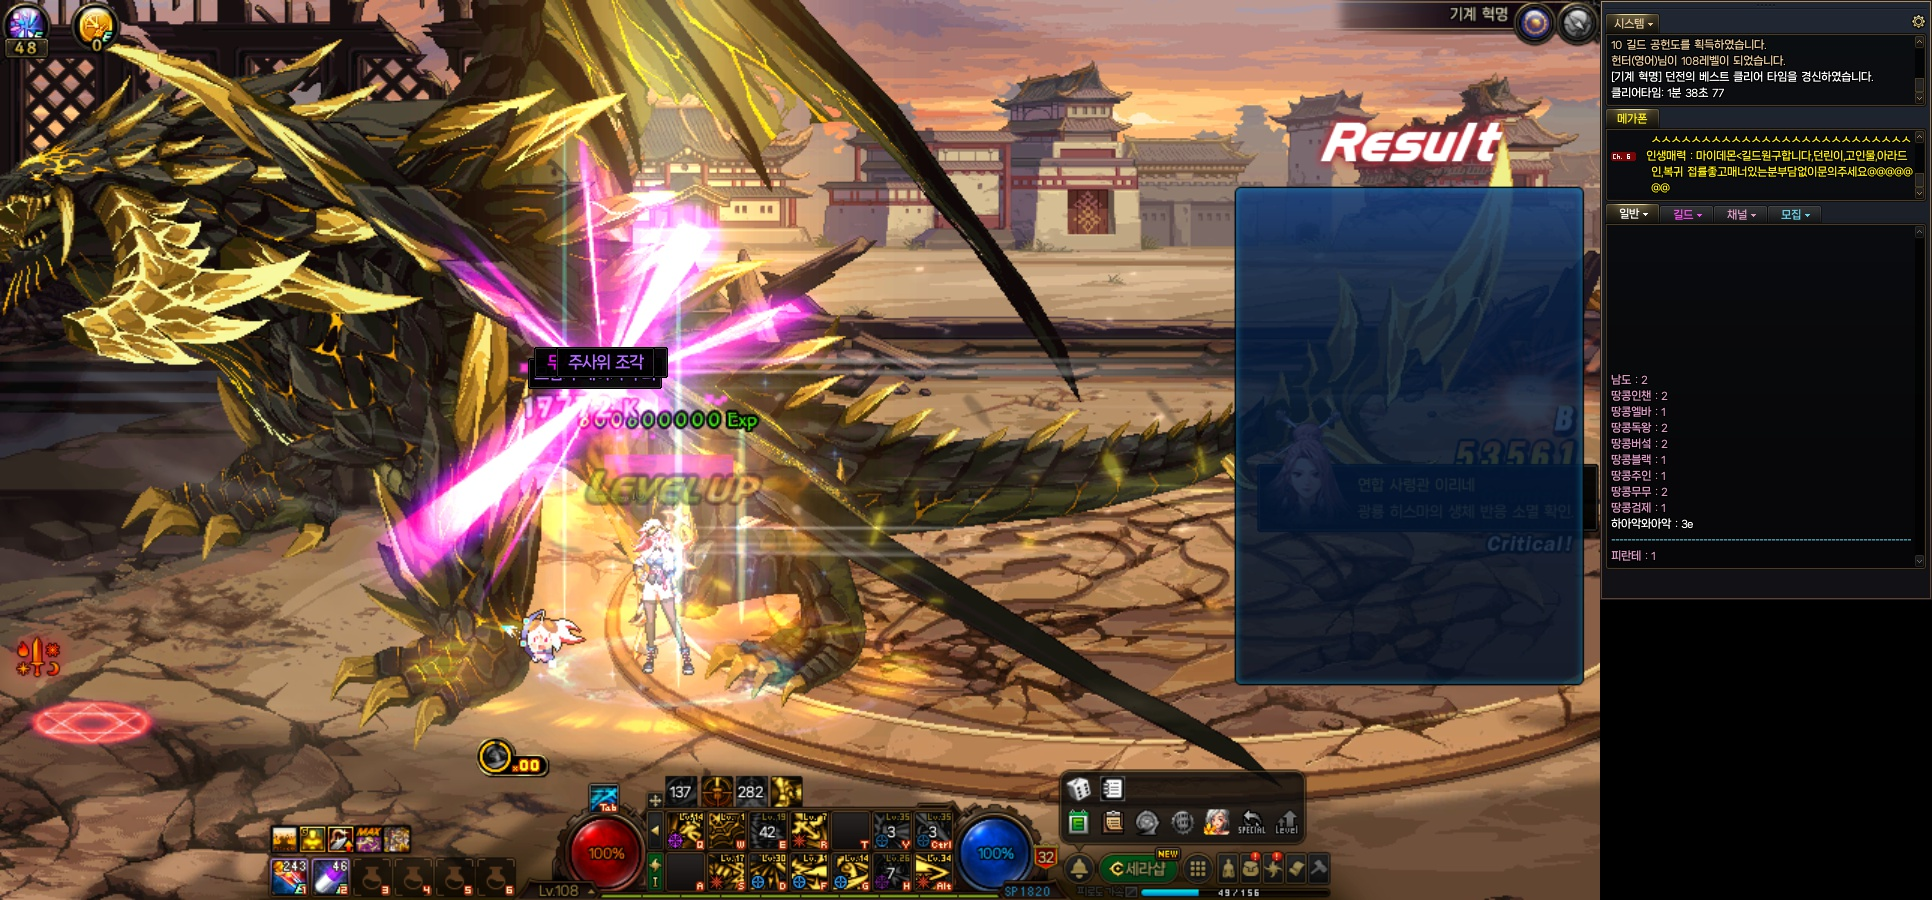

ScreenShot2024_0320_012420718.jpg


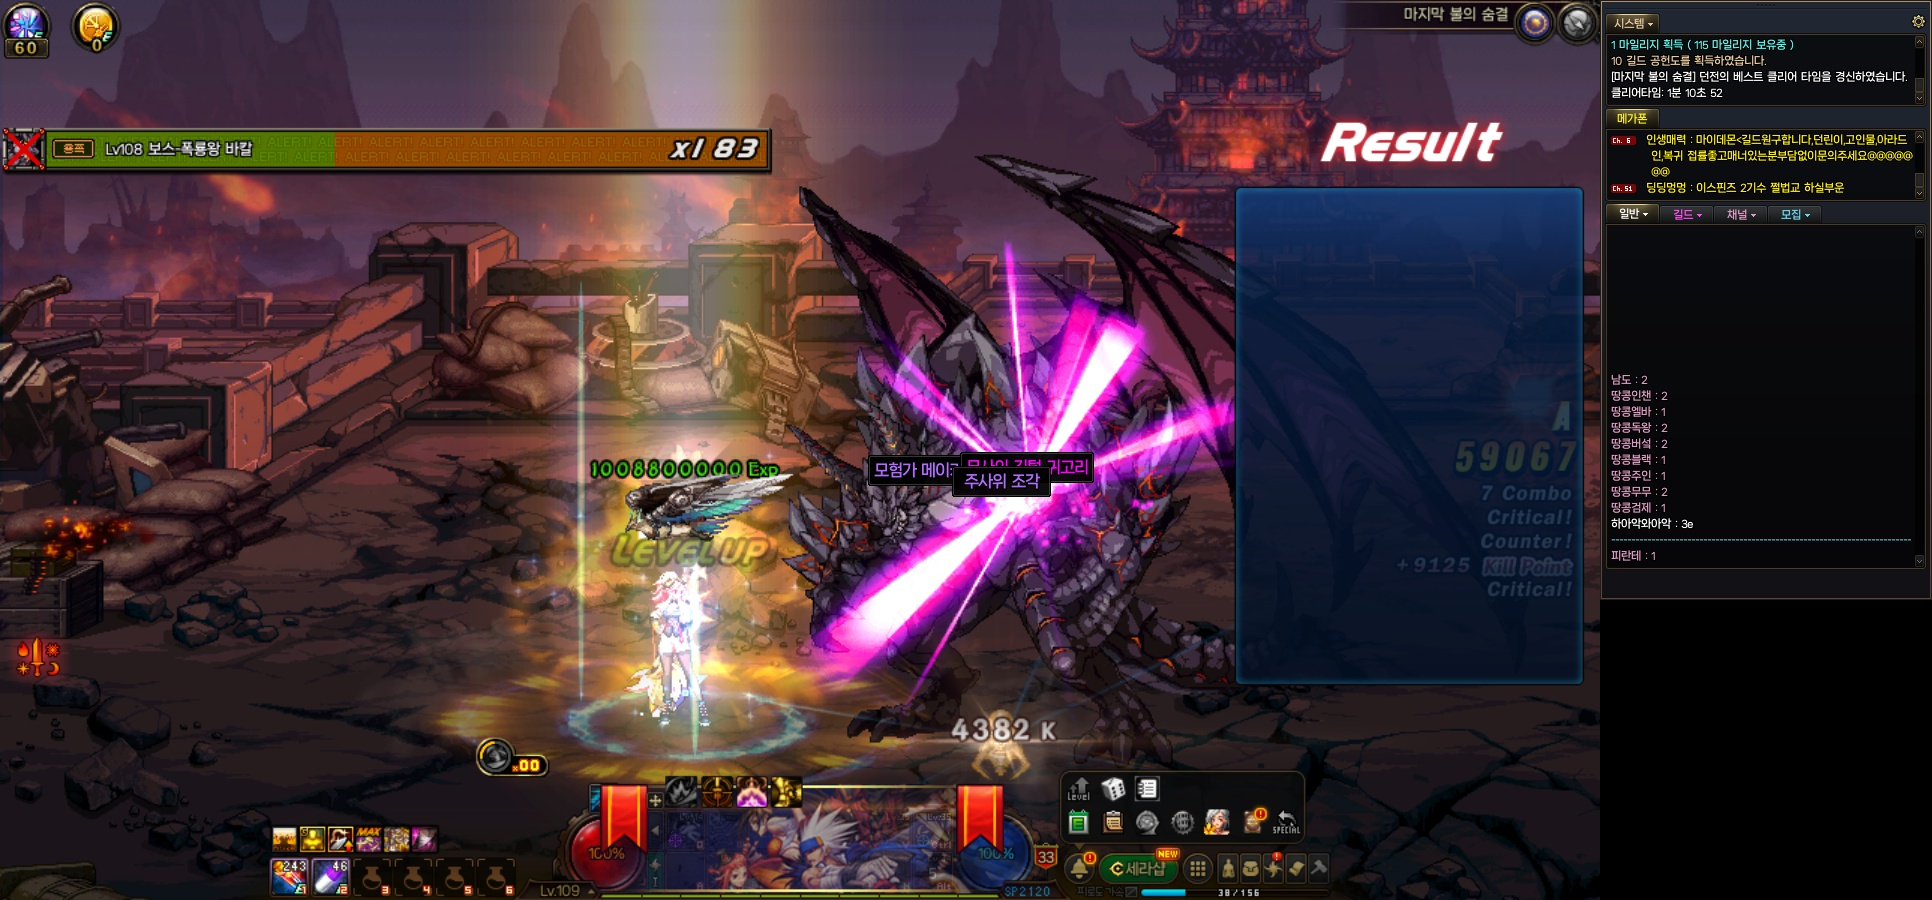

ScreenShot2025_0228_221905883.jpg


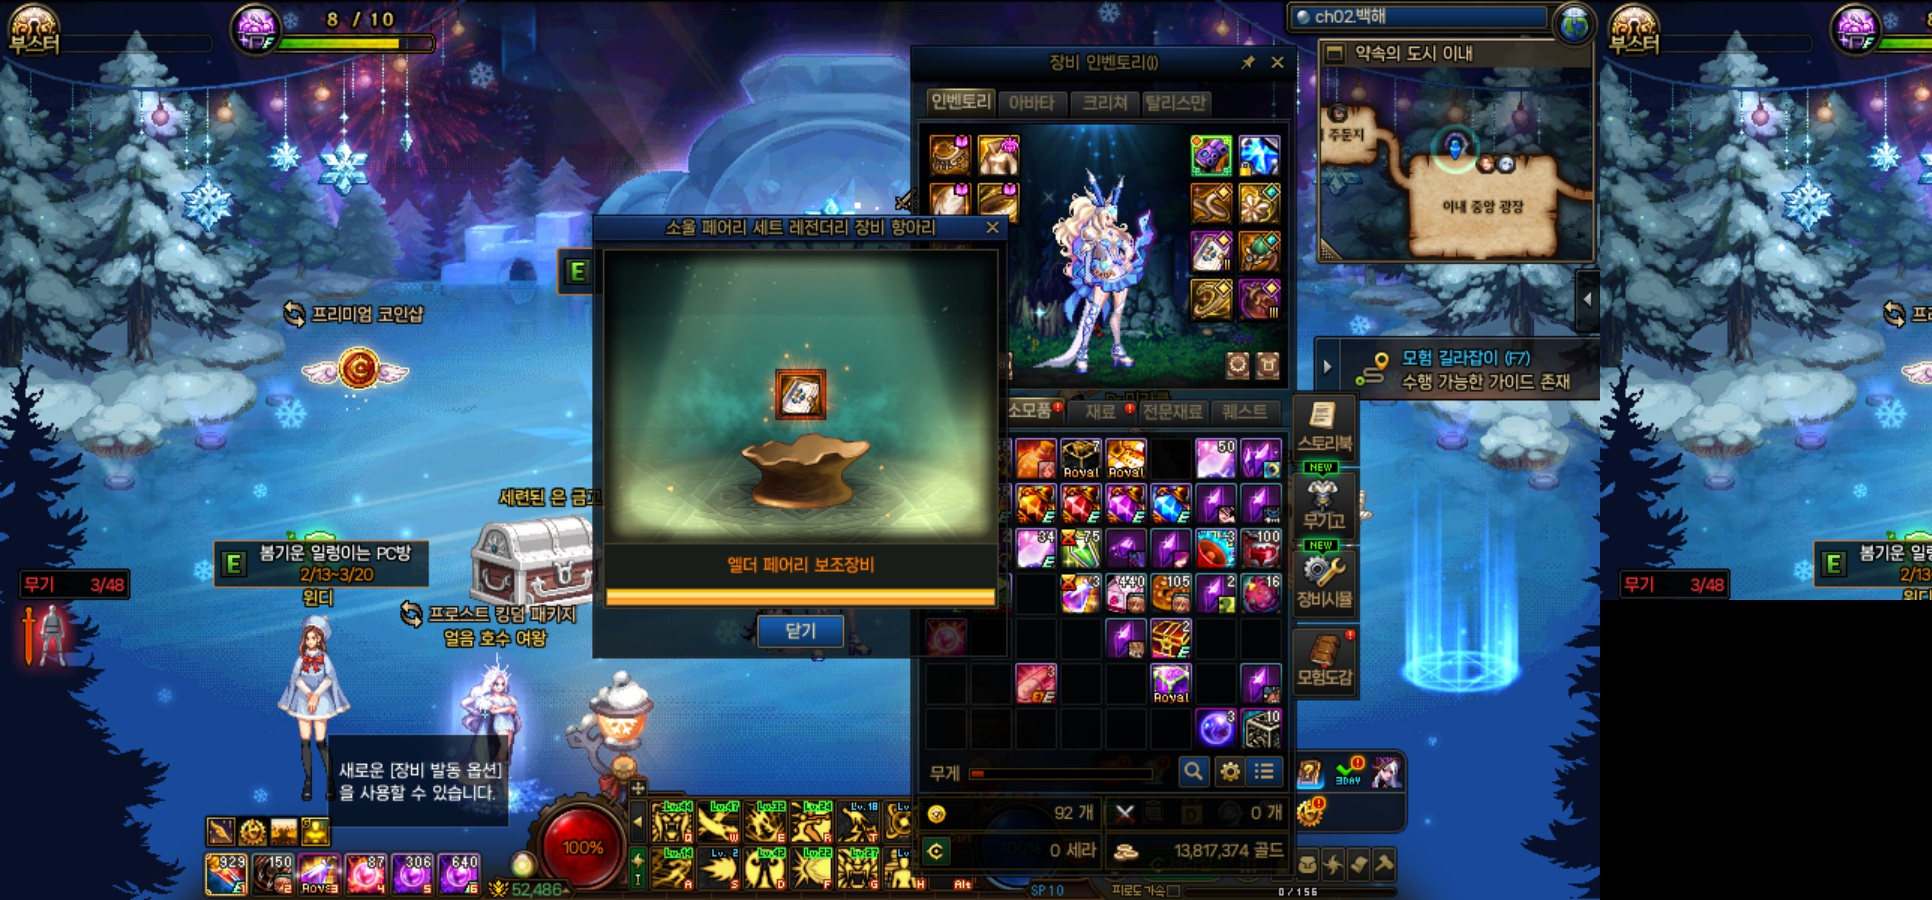

ScreenShot2025_0228_221911349.jpg


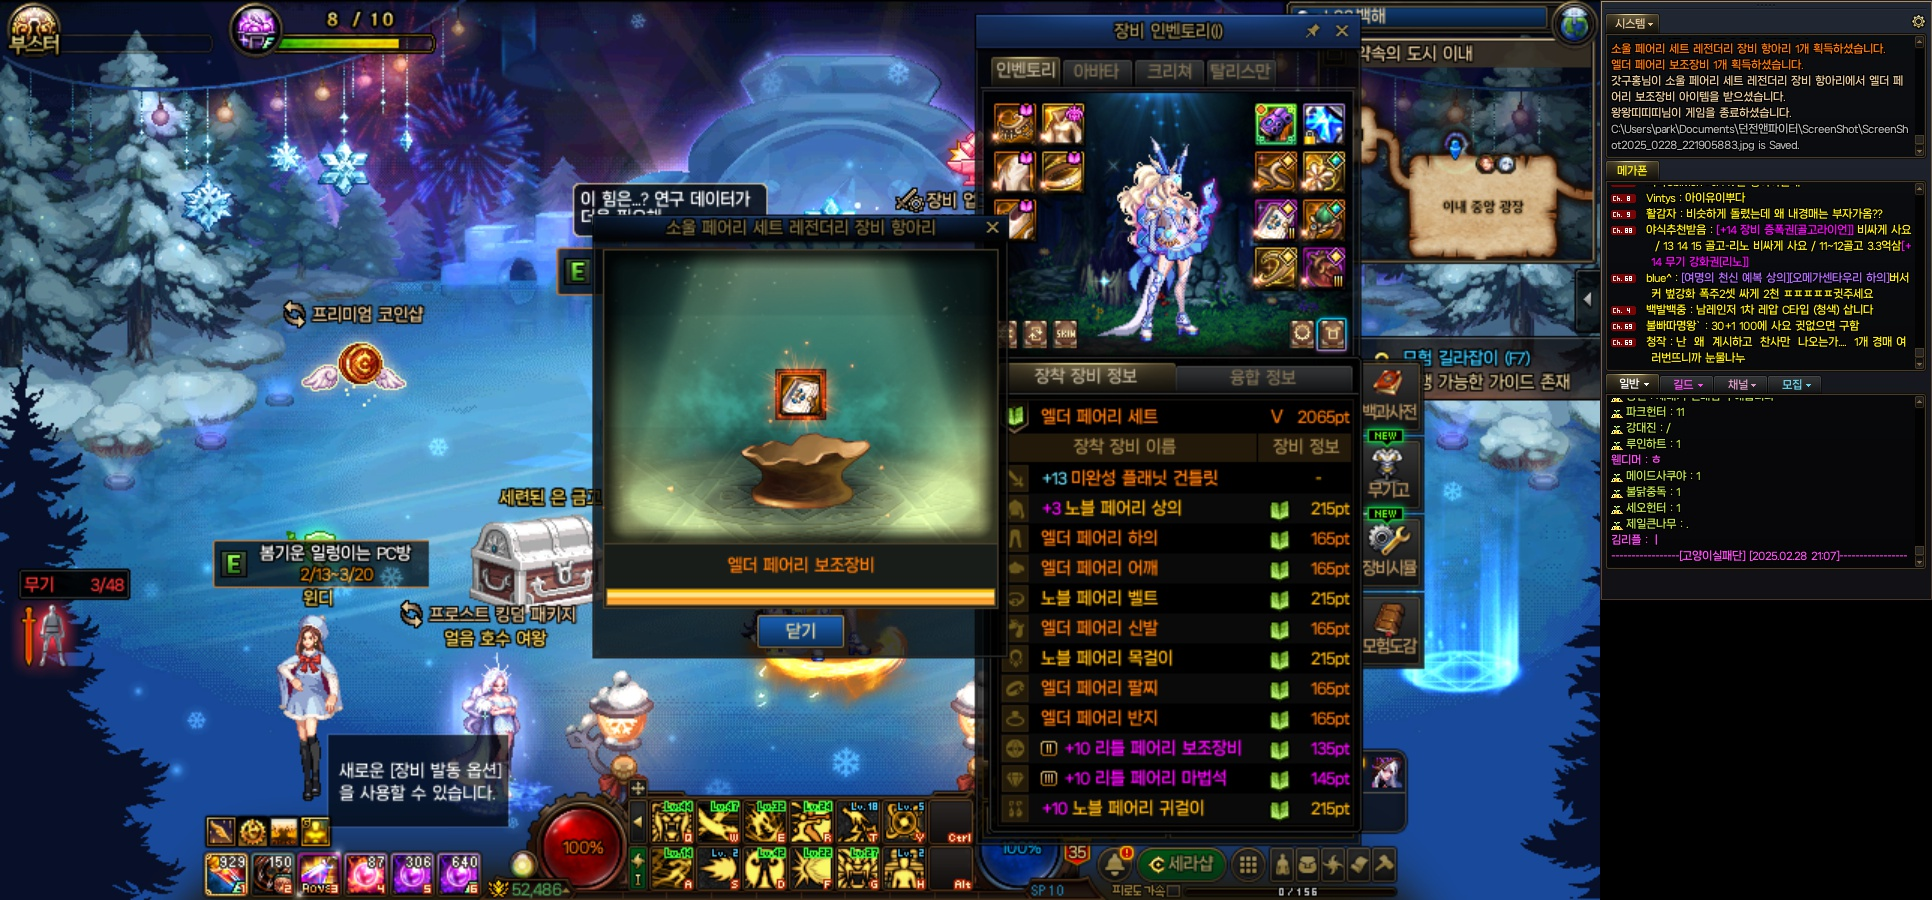

In [27]:
# ==================================================
# 실패 이미지 원본 확인
# 목적: 실제 닉네임이 없는 이미지인지 확인
# ==================================================

from IPython.display import Image, display

for filename in fail_df["filename"].head(10):
    img_path = TEST_IMAGES / filename

    print(filename)
    display(Image(filename=str(img_path)))

OCR 전체 처리 결과 169장 중 145장에서 닉네임 텍스트를 추출하였다.  
실패한 24장은 대부분 닉네임 영역이 존재하지 않거나 화면 내에서 명확히 식별되지 않는 이미지로 확인되었다.  
따라서 단순 OCR 실패율로 보기보다는, 탐지 대상 부재 이미지가 포함된 결과로 해석할 필요가 있다.

## YOLO + OCR 통합 실험 결과

총 169장의 테스트 이미지를 대상으로 실험을 수행하였다.

- 닉네임이 존재하는 이미지 : 145장
- 닉네임이 존재하지 않는 이미지 : 24장

YOLOv8s-960 모델을 통해 닉네임 영역(user_id)을 탐지한 후 EasyOCR을 적용하였다.

실험 결과 닉네임이 존재하는 145장의 이미지 모두에서 텍스트 추출이 가능하였다.

일부 이미지에서는 게임 폰트 특성으로 인해 OCR 오인식이 발생하였으나 후처리 규칙을 적용하여 정상적으로 보정하였다.

### 결과

| 항목 | 결과 |
|--------|--------:|
| 전체 이미지 | 169 |
| 닉네임 존재 이미지 | 145 |
| 닉네임 미존재 이미지 | 24 |
| OCR 성공 | 145 |
| OCR 실패 | 0 |
| OCR 성공률(닉네임 존재 기준) | 100% |

---

In [44]:
# ==================================================
# 매칭 테스트용 이미지 재선택 및 YOLO 재예측
# 목적: 전체 OCR 반복문에서 덮어써진 results/img를 다시 초기화
# ==================================================

# 캐릭터와 닉네임이 모두 보이는 테스트 이미지 선택
img_path = test_image_list[0]

# YOLO 재예측
results = model.predict(
    source=str(img_path),
    imgsz=960,
    conf=0.5,
    device=0,
    save=True
)

# 원본 이미지 다시 읽기
img = cv2.imread(str(img_path))

print("매칭 테스트 이미지:", img_path.name)
print(results[0].boxes)

Results saved to C:\Users\2-PC16\Desktop\NS-Project\runs\detect\predict-4
매칭 테스트 이미지: ScreenShot2024_0304_115450606.jpg
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 0.], device='cuda:0')
conf: tensor([0.8425, 0.7728], device='cuda:0')
data: tensor([[609.6442, 297.2996, 709.6865, 322.4576,   0.8425,   1.0000],
        [569.7432, 366.7794, 705.9404, 609.9750,   0.7728,   0.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (900, 1772)
shape: torch.Size([2, 6])
xywh: tensor([[659.6653, 309.8786, 100.0423,  25.1580],
        [637.8418, 488.3772, 136.1972, 243.1956]], device='cuda:0')
xywhn: tensor([[0.3723, 0.3443, 0.0565, 0.0280],
        [0.3600, 0.5426, 0.0769, 0.2702]], device='cuda:0')
xyxy: tensor([[609.6442, 297.2996, 709.6865, 322.4576],
        [569.7432, 366.7794, 705.9404, 609.9750]], device='cuda:0')
xyxyn: tensor([[0.3440, 0.3303, 0.4005, 0.3583],
        [0.3215, 0.4075, 0.3984, 0.6778]], device='cuda:0')


In [45]:
# ==================================================
# YOLO 박스 정보 추출
# 목적: user_id와 user_character 박스를 분리해서 저장
# ==================================================

boxes_info = []

for box in results[0].boxes:
    cls_id = int(box.cls[0])
    class_name = model.names[cls_id]
    conf = float(box.conf[0])

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    boxes_info.append({
        "class_name": class_name,
        "confidence": conf,
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2,
        "center_x": (x1 + x2) / 2,
        "center_y": (y1 + y2) / 2
    })

boxes_info

[{'class_name': 'user_id',
  'confidence': 0.842520534992218,
  'x1': 609,
  'y1': 297,
  'x2': 709,
  'y2': 322,
  'center_x': 659.0,
  'center_y': 309.5},
 {'class_name': 'user_character',
  'confidence': 0.772839367389679,
  'x1': 569,
  'y1': 366,
  'x2': 705,
  'y2': 609,
  'center_x': 637.0,
  'center_y': 487.5}]

In [46]:
# ==================================================
# 클래스별 박스 분리
# 목적: 닉네임 박스와 캐릭터 박스를 따로 관리
# ==================================================

user_id_boxes = [
    box for box in boxes_info
    if box["class_name"] == "user_id"
]

character_boxes = [
    box for box in boxes_info
    if box["class_name"] == "user_character"
]

print("user_id 개수:", len(user_id_boxes))
print("character 개수:", len(character_boxes))

user_id 개수: 1
character 개수: 1


In [47]:
# ==================================================
# 닉네임-캐릭터 매칭 개선 버전
# 목적: 닉네임과 가장 가까운 캐릭터를 거리 기반으로 연결
# ==================================================

matched_results = []

for user_box in user_id_boxes:

    best_character = None
    best_score = float("inf")

    for char_box in character_boxes:

        # 닉네임 중심과 캐릭터 중심의 거리 계산
        x_distance = abs(user_box["center_x"] - char_box["center_x"])
        y_distance = abs(user_box["center_y"] - char_box["center_y"])

        # x축 거리를 더 중요하게 반영
        score = (x_distance * 1.5) + y_distance

        if score < best_score:
            best_score = score
            best_character = char_box

    matched_results.append({
        "nickname_box": user_box,
        "character_box": best_character,
        "match_score": best_score if best_character is not None else None
    })

matched_results

[{'nickname_box': {'class_name': 'user_id',
   'confidence': 0.842520534992218,
   'x1': 609,
   'y1': 297,
   'x2': 709,
   'y2': 322,
   'center_x': 659.0,
   'center_y': 309.5},
  'character_box': {'class_name': 'user_character',
   'confidence': 0.772839367389679,
   'x1': 569,
   'y1': 366,
   'x2': 705,
   'y2': 609,
   'center_x': 637.0,
   'center_y': 487.5},
  'match_score': 211.0}]

In [48]:
# ==================================================
# OCR 닉네임과 캐릭터 매칭 결과 결합
# 목적: 최종적으로 닉네임 텍스트와 캐릭터 위치를 하나로 정리
# ==================================================

final_results = []

for match in matched_results:

    user_box = match["nickname_box"]
    char_box = match["character_box"]

    # user_id crop
    x1, y1, x2, y2 = user_box["x1"], user_box["y1"], user_box["x2"], user_box["y2"]
    crop = img[y1:y2, x1:x2]

    crop_big = cv2.resize(
        crop,
        None,
        fx=4,
        fy=4,
        interpolation=cv2.INTER_CUBIC
    )

    ocr_result = reader.readtext(
        crop_big,
        detail=1,
        paragraph=False,
        text_threshold=0.4,
        low_text=0.2,
        link_threshold=0.4,
        mag_ratio=2
    )

    for bbox, text, conf in ocr_result:
        corrected_text = correct_nickname(text)

        final_results.append({
            "nickname": corrected_text,
            "ocr_text": text,
            "ocr_confidence": round(conf, 4),
            "user_id_confidence": round(user_box["confidence"], 4),
            "character_confidence": round(char_box["confidence"], 4) if char_box else None,
            "character_box": char_box
        })

final_results

[{'nickname': '부끄러운게임',
  'ocr_text': '부끄러움게임',
  'ocr_confidence': np.float64(0.8789),
  'user_id_confidence': 0.8425,
  'character_confidence': 0.7728,
  'character_box': {'class_name': 'user_character',
   'confidence': 0.772839367389679,
   'x1': 569,
   'y1': 366,
   'x2': 705,
   'y2': 609,
   'center_x': 637.0,
   'center_y': 487.5}}]

In [49]:
# ==================================================
# 최종 매칭 결과 DataFrame 생성
# 목적: 닉네임과 캐릭터 매칭 결과를 표로 확인
# ==================================================

import pandas as pd

match_df = pd.DataFrame(final_results)

match_df

,nickname,ocr_text,ocr_confidence,user_id_confidence,character_confidence,character_box
0,부끄러운게임,부끄러움게임,0.8789,0.8425,0.7728,"{'class_name': 'user_character', 'confidence':..."


In [51]:
# ==================================================
# 전체 이미지 매칭 결과 저장 리스트
# 목적: 이미지별 닉네임-OCR-캐릭터 매칭 결과 저장
# ==================================================

match_rows = []

In [59]:
# ==================================================
# test/images 전체 캐릭터-닉네임 박스 매칭
# 목적: 모든 테스트 이미지에서 user_id 박스와 user_character 박스를 연결
# ==================================================

match_rows = []

for img_path in TEST_IMAGES.glob("*"):

    print(f"처리중: {img_path.name}")

    results = model.predict(
        source=str(img_path),
        imgsz=960,
        conf=0.5,
        device=0,
        verbose=False
    )

    boxes_info = []

    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        class_name = model.names[cls_id]
        det_conf = float(box.conf[0])

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        boxes_info.append({
            "class_name": class_name,
            "confidence": det_conf,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "center_x": (x1 + x2) / 2,
            "center_y": (y1 + y2) / 2
        })

    user_id_boxes = [
        box for box in boxes_info
        if box["class_name"] == "user_id"
    ]

    character_boxes = [
        box for box in boxes_info
        if box["class_name"] == "user_character"
    ]

    if len(user_id_boxes) == 0:
        match_rows.append({
            "filename": img_path.name,
            "user_id_confidence": None,
            "character_confidence": None,
            "match_score": None,
            "user_id_box": None,
            "character_box": None,
            "status": "no_user_id"
        })
        continue

    for user_box in user_id_boxes:

        best_character = None
        best_score = None

        if len(character_boxes) > 0:
            best_score = float("inf")

            for char_box in character_boxes:
                x_distance = abs(user_box["center_x"] - char_box["center_x"])
                y_distance = abs(user_box["center_y"] - char_box["center_y"])

                score = (x_distance * 1.5) + y_distance

                if score < best_score:
                    best_score = score
                    best_character = char_box

        match_rows.append({
            "filename": img_path.name,
            "user_id_confidence": round(user_box["confidence"], 4),
            "character_confidence": round(best_character["confidence"], 4) if best_character else None,
            "match_score": round(best_score, 2) if best_score is not None else None,
            "user_id_box": (user_box["x1"], user_box["y1"], user_box["x2"], user_box["y2"]),
            "character_box": (
                best_character["x1"],
                best_character["y1"],
                best_character["x2"],
                best_character["y2"]
            ) if best_character else None,
            "status": "matched" if best_character else "user_id_only"
        })

처리중: ScreenShot2024_0304_115450606.jpg
처리중: ScreenShot2024_0304_141339663.jpg
처리중: ScreenShot2024_0307_222002013.jpg
처리중: ScreenShot2024_0307_231808909.jpg
처리중: ScreenShot2024_0307_234814460.jpg
처리중: ScreenShot2024_0308_005112729.jpg
처리중: ScreenShot2024_0308_213117869.jpg
처리중: ScreenShot2024_0308_225451866.jpg
처리중: ScreenShot2024_0309_195729375.jpg
처리중: ScreenShot2024_0309_202918770.jpg
처리중: ScreenShot2024_0310_191122177.jpg
처리중: ScreenShot2024_0310_194737263.jpg
처리중: ScreenShot2024_0311_164506563.jpg
처리중: ScreenShot2024_0311_181930117.jpg
처리중: ScreenShot2024_0311_182406074.jpg
처리중: ScreenShot2024_0311_182447074.jpg
처리중: ScreenShot2024_0312_121803791.jpg
처리중: ScreenShot2024_0314_004025247.jpg
처리중: ScreenShot2024_0314_021040099.jpg
처리중: ScreenShot2024_0314_161245344.jpg
처리중: ScreenShot2024_0314_191918145.jpg
처리중: ScreenShot2024_0314_220100769.jpg
처리중: ScreenShot2024_0315_015624003.jpg
처리중: ScreenShot2024_0315_050405529.jpg
처리중: ScreenShot2024_0316_182000455.jpg
처리중: ScreenShot2024_0316_

In [60]:
import pandas as pd

match_all_df = pd.DataFrame(match_rows)
match_all_df

,filename,user_id_confidence,character_confidence,match_score,user_id_box,character_box,status
0,ScreenShot2024_0304_115450606.jpg,0.8425,0.7728,211.00,"(609, 297, 709, 322)","(569, 366, 705, 609)",matched
1,ScreenShot2024_0304_141339663.jpg,0.5516,NaN,NaN,"(704, 330, 762, 353)",None,user_id_only
2,ScreenShot2024_0307_222002013.jpg,0.8402,0.7795,196.00,"(583, 380, 685, 404)","(585, 448, 705, 695)",matched
3,ScreenShot2024_0307_231808909.jpg,NaN,NaN,NaN,None,None,no_user_id
4,ScreenShot2024_0307_234814460.jpg,0.7938,0.7008,216.75,"(499, 407, 583, 433)","(449, 509, 578, 682)",matched
...,...,...,...,...,...,...,...
163,ScreenShot2025_1011_111835902.jpg,0.7797,NaN,NaN,"(243, 458, 317, 478)",None,user_id_only
164,ScreenShot2025_1012_102530892.jpg,0.8230,0.8716,99.25,"(126, 418, 195, 437)","(122, 446, 192, 597)",matched
165,ScreenShot2025_1015_021459396.jpg,0.8072,0.7570,115.75,"(1228, 525, 1308, 545)","(1216, 555, 1295, 709)",matched
166,ScreenShot2025_1015_021623232.jpg,NaN,NaN,NaN,None,None,no_user_id


In [64]:
# =================================================
# 매칭 상태별 개수 확인
# 목적: 전체 이미지에서 매칭 성공/실패 비율 확인
# =================================================
match_all_df["status"].value_counts()

status
matched         119
user_id_only     25
no_user_id       24
Name: count, dtype: int64

In [65]:
# ==================================================
# 매칭 성공률 계산
# 목적: user_id가 탐지된 이미지 중 캐릭터와 매칭된 비율 확인
# ==================================================

total = len(match_all_df)
matched = (match_all_df["status"] == "matched").sum()
user_id_only = (match_all_df["status"] == "user_id_only").sum()
no_user_id = (match_all_df["status"] == "no_user_id").sum()

print("전체 결과:", total)
print("매칭 성공:", matched)
print("닉네임만 탐지:", user_id_only)
print("닉네임 없음:", no_user_id)
print("매칭 성공률:", round(matched / (matched + user_id_only) * 100, 2), "%")

전체 결과: 168
매칭 성공: 119
닉네임만 탐지: 25
닉네임 없음: 24
매칭 성공률: 82.64 %


In [62]:
match_csv_path = PROJECT_ROOT / "yolo_box_match_result.csv"

match_all_df.to_csv(
    match_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print(match_csv_path)

c:\Users\금정산2-PC16\Desktop\NS-Project\yolo_box_match_result.csv


In [66]:
# user_id는 있지만 캐릭터가 탐지되지 않은 이미지 확인
user_id_only_df = match_all_df[match_all_df["status"] == "user_id_only"]

user_id_only_df[["filename", "user_id_confidence", "user_id_box"]]

,filename,user_id_confidence,user_id_box
1,ScreenShot2024_0304_141339663.jpg,0.5516,"(704, 330, 762, 353)"
6,ScreenShot2024_0308_213117869.jpg,0.8230,"(613, 415, 691, 437)"
9,ScreenShot2024_0309_202918770.jpg,0.5512,"(744, 436, 829, 460)"
10,ScreenShot2024_0309_202918770.jpg,0.5151,"(744, 436, 801, 460)"
12,ScreenShot2024_0310_194737263.jpg,0.7734,"(790, 433, 824, 453)"
13,ScreenShot2024_0311_164506563.jpg,0.8321,"(613, 306, 694, 330)"
14,ScreenShot2024_0311_181930117.jpg,0.6905,"(637, 478, 679, 501)"
32,ScreenShot2024_0318_011013069.jpg,0.7885,"(847, 423, 941, 446)"
33,ScreenShot2024_0318_011800183.jpg,0.8261,"(827, 510, 920, 533)"
36,ScreenShot2024_0318_213721758.jpg,0.8232,"(787, 352, 873, 377)"


In [70]:
# ==================================================
# 캐릭터 미탐지 원인별 개수 확인
# ==================================================

user_id_only_df["reason"].value_counts()

reason
    25
Name: count, dtype: int64

In [71]:
# ==================================================
# 캐릭터 미탐지 원인 분석 결과 저장
# ==================================================

analysis_path = PROJECT_ROOT / "character_miss_analysis.csv"

user_id_only_df.to_csv(
    analysis_path,
    index=False,
    encoding="utf-8-sig"
)

print(analysis_path)

c:\Users\금정산2-PC16\Desktop\NS-Project\character_miss_analysis.csv



---
### 원인별 개선 방향

In [72]:
# ==================================================
# 원인별 개선 방향 요약
# ==================================================

reason_summary = user_id_only_df["reason"].value_counts()

reason_summary

reason
    25
Name: count, dtype: int64

캐릭터-닉네임 매칭 결과, 닉네임은 탐지되었으나 캐릭터가 탐지되지 않은 이미지가 25장 확인되었다.  
해당 이미지를 육안 검수한 결과, 대부분 실제 캐릭터가 존재했으나 작은 크기, 가림, 이펙트, 학습 데이터에 부족한 캐릭터 형태 등으로 인해 미탐지된 것으로 분석되었다.  
따라서 후속 개선 방향은 OCR 보정보다 캐릭터 탐지 성능 개선에 초점을 맞추는 것이 적절하다.

In [73]:
# ==================================================
# user_id_only 이미지 복사
# 목적: 닉네임은 탐지됐지만 캐릭터가 미탐지된 이미지 25장 검토용 폴더 생성
# ==================================================

import shutil
from pathlib import Path

# user_id_only 데이터만 추출
user_id_only_df = match_all_df[
    match_all_df["status"] == "user_id_only"
].copy()

# 검토용 폴더 생성
review_dir = PROJECT_ROOT / "data" / "review" / "user_id_only_images"
review_dir.mkdir(parents=True, exist_ok=True)

# 이미지 복사
for filename in user_id_only_df["filename"]:
    src = TEST_IMAGES / filename
    dst = review_dir / filename

    if src.exists():
        shutil.copy2(src, dst)
    else:
        print("파일 없음:", src)

print("복사 완료:", len(list(review_dir.glob('*'))))
print("저장 위치:", review_dir)

복사 완료: 24
저장 위치: c:\Users\금정산2-PC16\Desktop\NS-Project\data\review\user_id_only_images
